In [159]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("Pandas version:", pd.__version__)

Pandas version: 3.0.1


In [ ]:
# Load the dataset
df = pd.read_csv("/Users/riki/Documents/applied-ml-classic/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [9]:
#check first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
#Row and collumns dataset
print(f"Shape dataset: {df.shape}")

Shape dataset: (7043, 21)


In [11]:
#check for memory usage, null count and dtype each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [103]:
# statistic for mean, min, max
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [138]:
df.describe(include=['object'])


/var/folders/f1/df8mrxcs5n9fz7hj5fhm9xx40000gn/T/ipykernel_2650/1980305844.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


# summary of data inspection :
1. total row is around 7k with 21 column
2. All row is safe from null value, no null value found
3. Total charge is number, need to change Dtypes to float64. Precaution: handle potential empty strings during conversion.
4. Skewness Strategy: tenure (Right Skew) and MonthlyCharges (Left Skew) show mild skewness.

Since we plan to use Tree-based models, no transformation is required as they are invariant to monotonic transformations.

For Logistic Regression, we will monitor the performance; if the model struggles, we might reconsider Scaling or Power Transformation later.

Next we focus on checking missing value and duplicates, in preparation for cleaning engineering

In [112]:
# check for null/nan in each column
missing_data = df.isnull().sum()
print(f"missing data:\n{missing_data}")

missing data:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [130]:
# check missing data percentage
missing_percentage = (df.isnull().mean() * 100).round(1)
print(f"percentage missing value :\n{missing_percentage} ")

percentage missing value :
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.2
Churn               0.0
dtype: float64 


In [28]:
# check duplicated data
print(f"Duplicated row : {df.duplicated().sum()}")

Duplicated row : 0


# conclusion
No missing value or duplicate

# Univariate Analysis

In [163]:
# Check data variation
# Convert TotalCharges to int (kalau ada spasi/error, coerce ke NaN—tapi missing 0, aman)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# divid number and text column and remove customer
categorical_cols =df.select_dtypes(include=['object','category']).columns.drop('customerID' ,errors='ignore').tolist()

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical cols:", categorical_cols)
print("Numerical cols:", numerical_cols)

Categorical cols: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Numerical cols: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


/var/folders/f1/df8mrxcs5n9fz7hj5fhm9xx40000gn/T/ipykernel_2650/3168995958.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols =df.select_dtypes(include=['object','category']).columns.drop('customerID' ,errors='ignore').tolist()


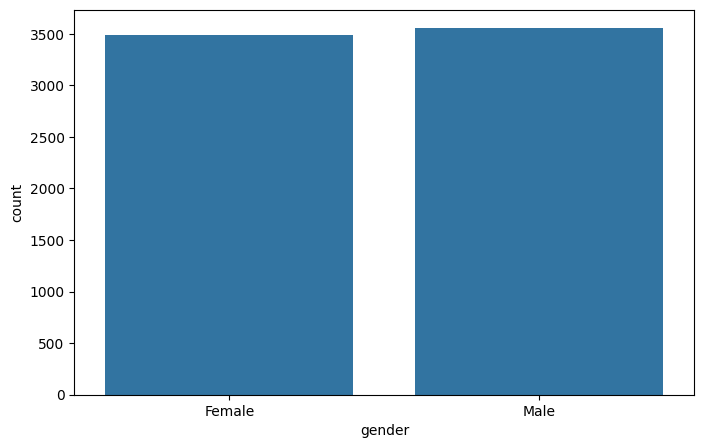

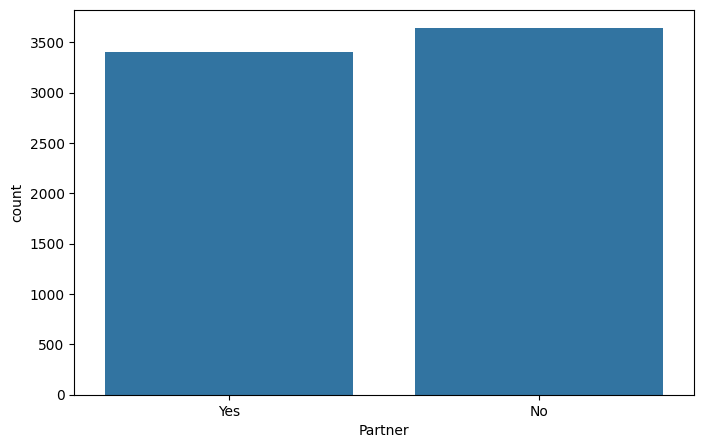

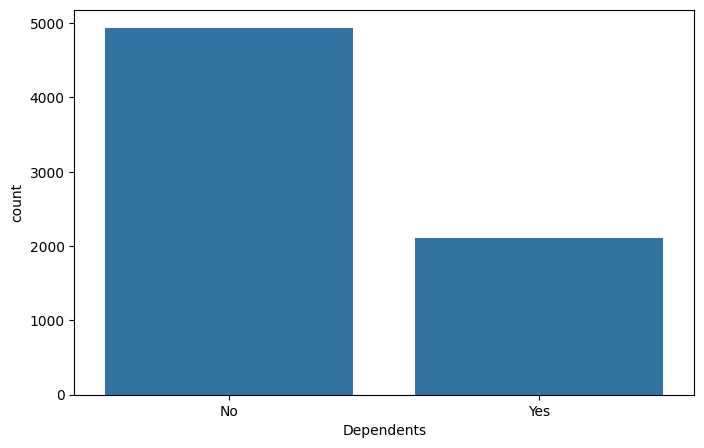

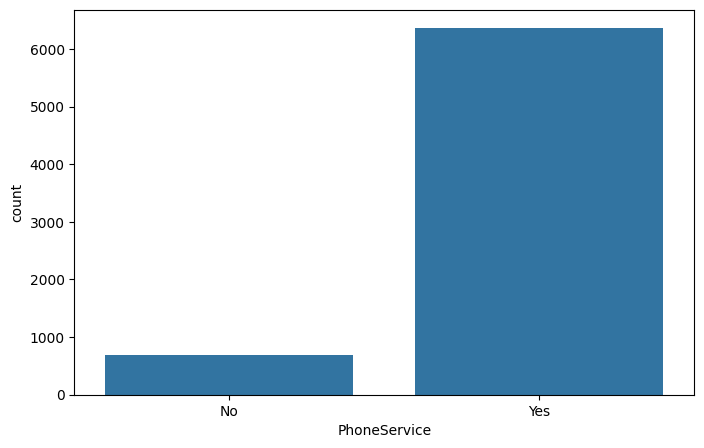

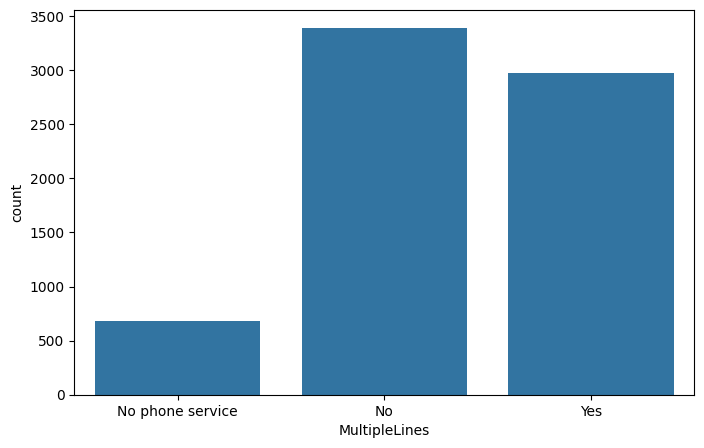

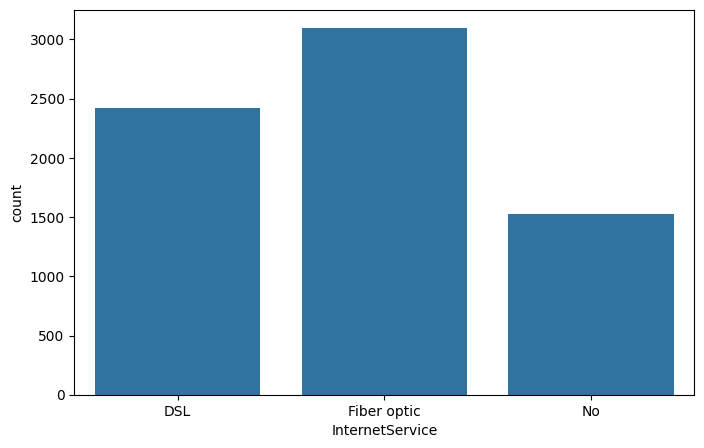

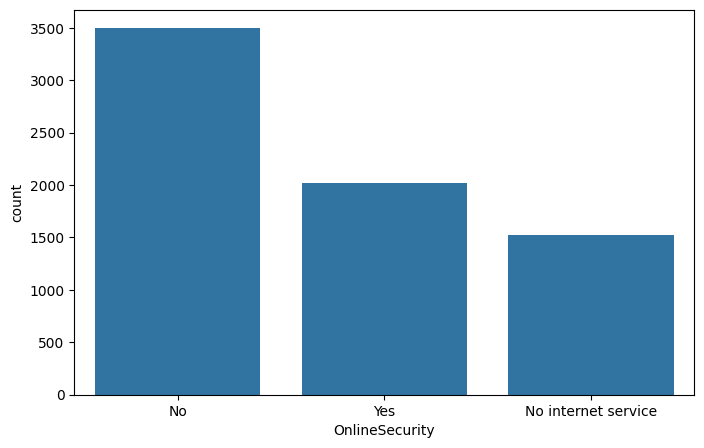

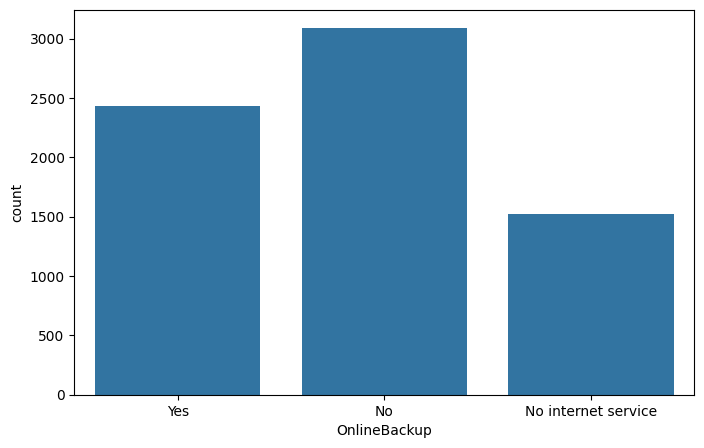

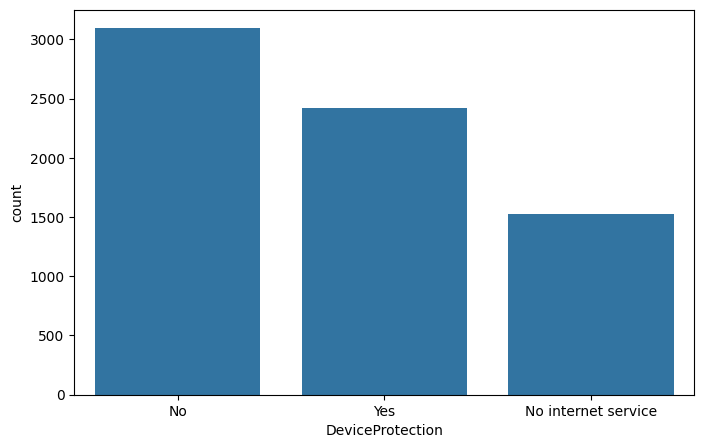

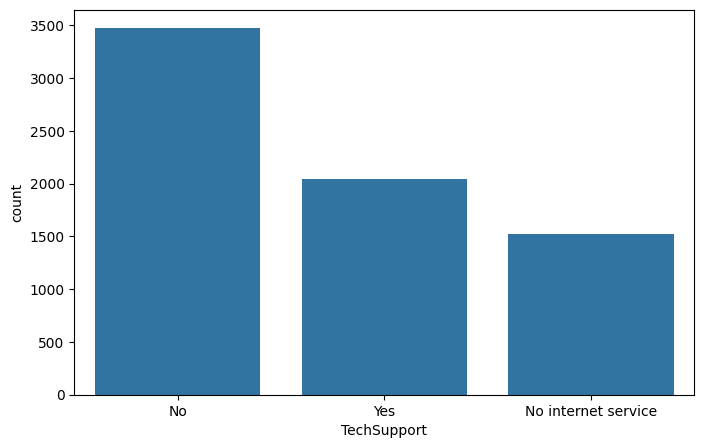

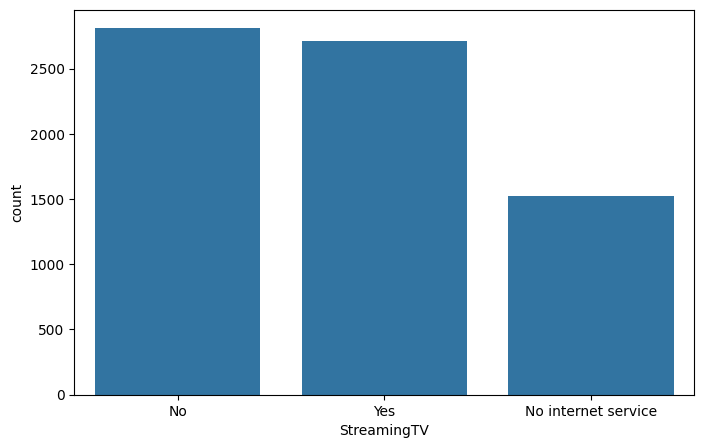

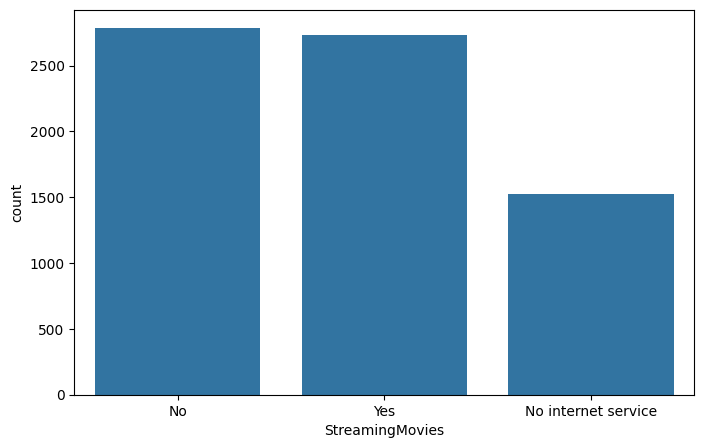

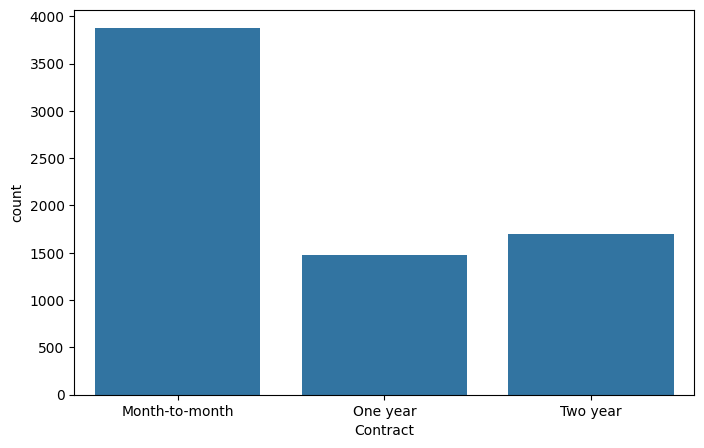

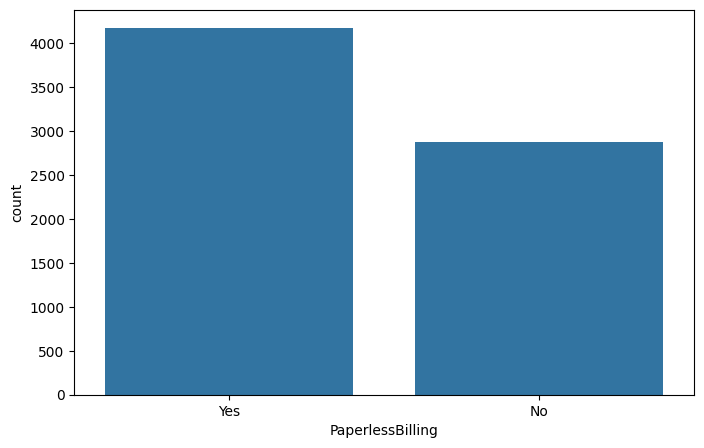

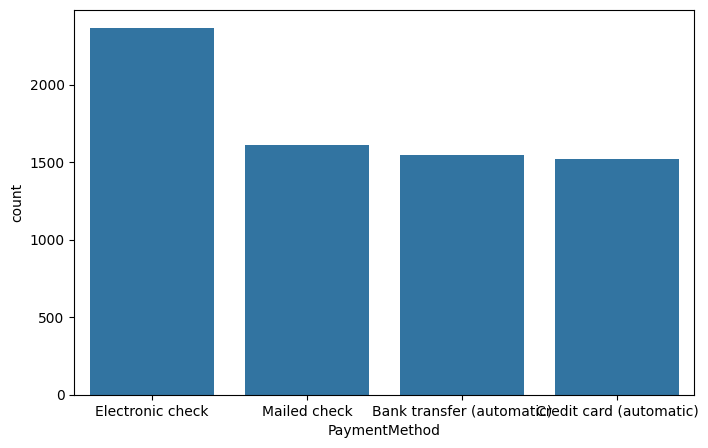

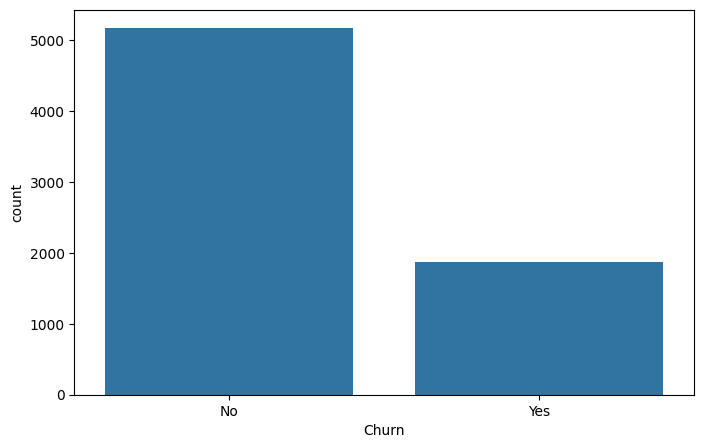

In [144]:
# Univariate Categorical
for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col)
    plt.show  

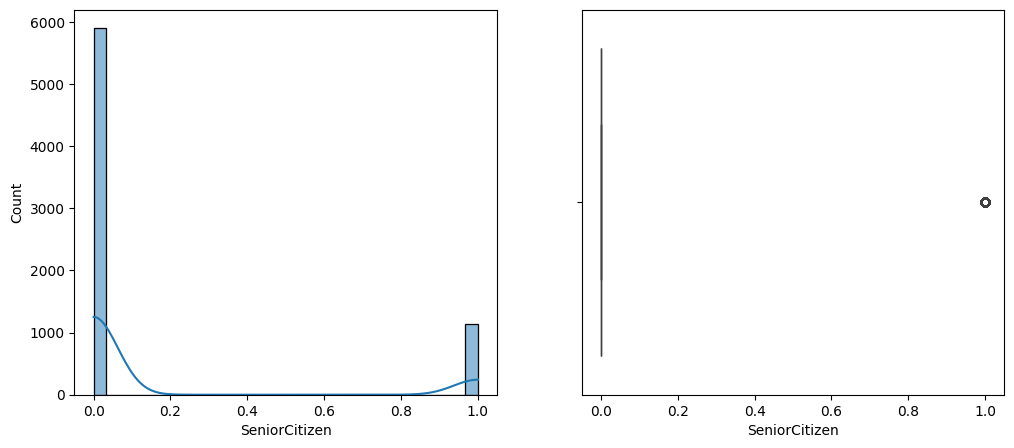

SeniorCitizen - skewness 1.83 , - kurtosis 1.36


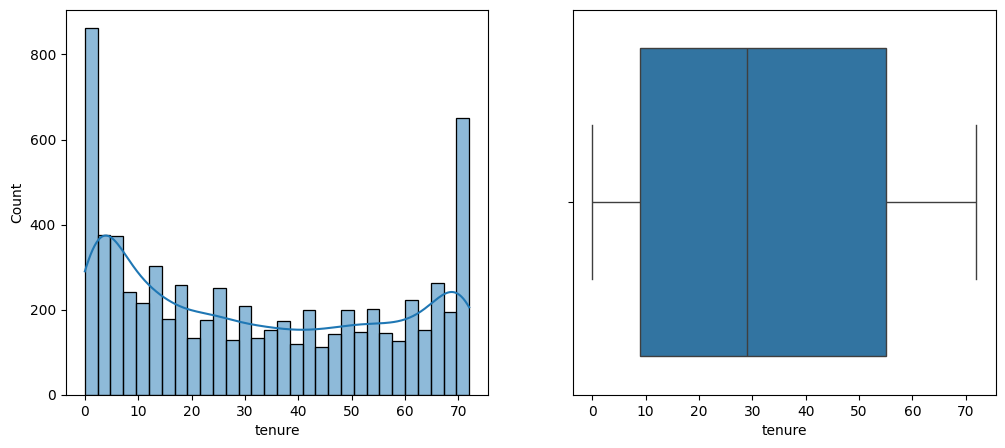

tenure - skewness 0.24 , - kurtosis -1.39


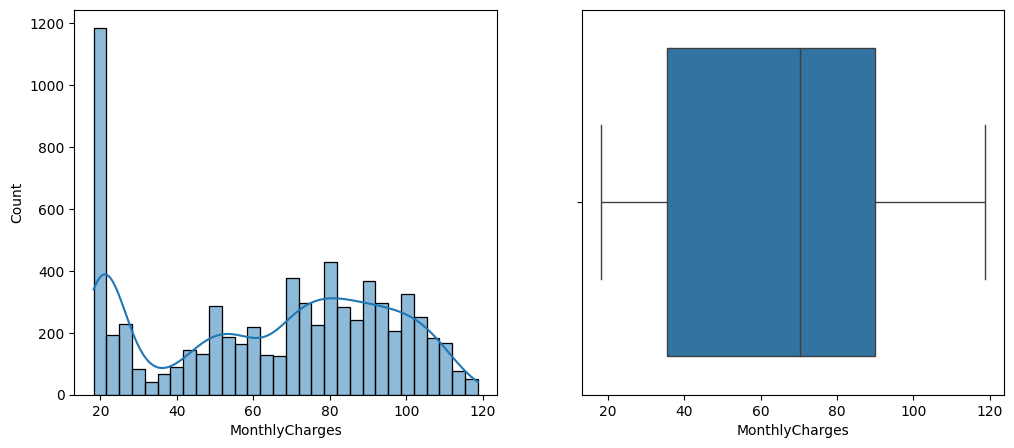

MonthlyCharges - skewness -0.22 , - kurtosis -1.26


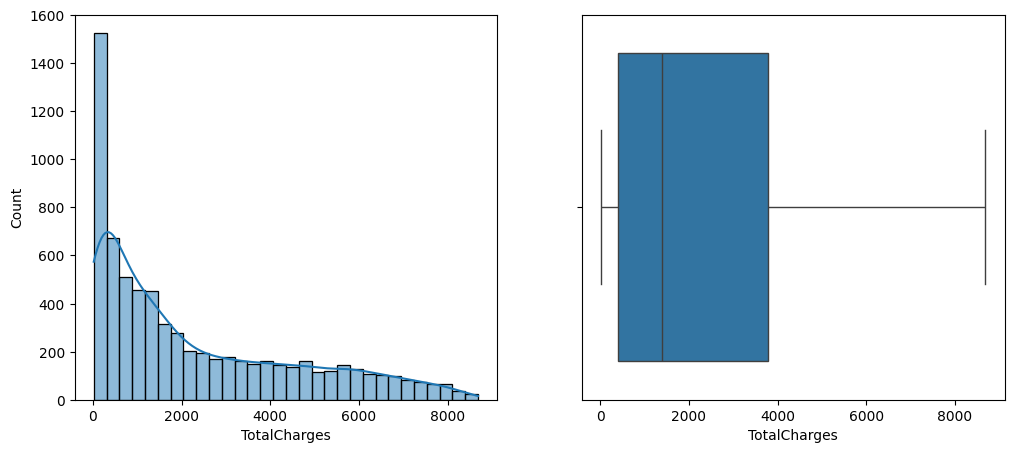

TotalCharges - skewness 0.96 , - kurtosis -0.23


In [152]:
# Univariate Number
for col in numerical_cols:
    plt.figure(figsize=(12, 5))
    
    # Histogram + KDE
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=30, kde=True)
    
    # Boxplot untuk outlier
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    
    plt.show()
    
    # Bonus stats: Check skewness and kurtosis
    print(f"{col} - skewness {df[col].skew():.2f} , - kurtosis {df[col].kurt():.2f}")
    

# summary of data inspection :
1. Target (Churn) is moderately imbalanced.
PhoneService is dominated by one category.
2. No significant outliers detected using boxplot/IQR inspection.
3. Most numeric features show positive (right) skewness,
especially TotalCharges and tenure.

# implication :
1. Use stratified train-test split to preserve class distribution.
Consider class_weight or imbalance-aware metrics (F1, ROC-AUC).
PhoneService may provide limited predictive power due to low variance.
2. Outlier clipping or winsorization is not required.
Standard preprocessing should be sufficient.
3. Consider log1p transformation to reduce skewness.
Tree-based models may not require transformation,
but linear or distance-based models can benefit.

# Bivariate  analysis

In [ ]:
# Remove target churn and move Senior citizen as categorical
categorical_cols.remove("Churn")
numerical_cols.remove("SeniorCitizen")
categorical_cols.append("SeniorCitizen")

<Figure size 600x400 with 0 Axes>

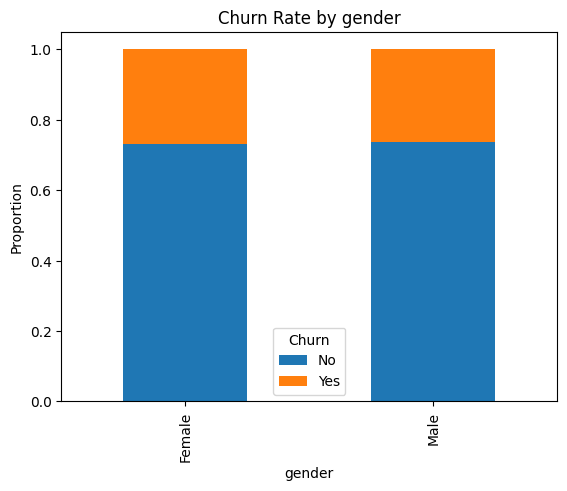

<Figure size 600x400 with 0 Axes>

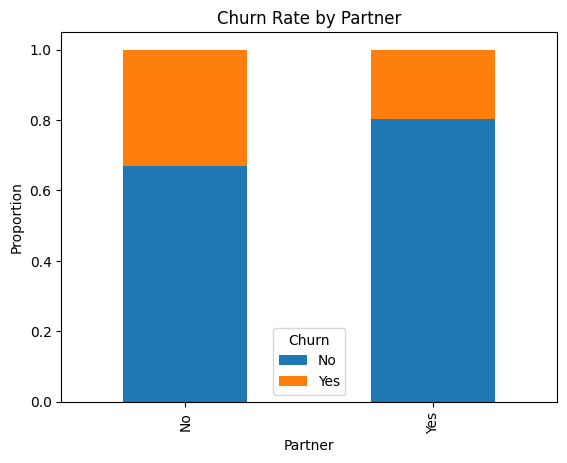

<Figure size 600x400 with 0 Axes>

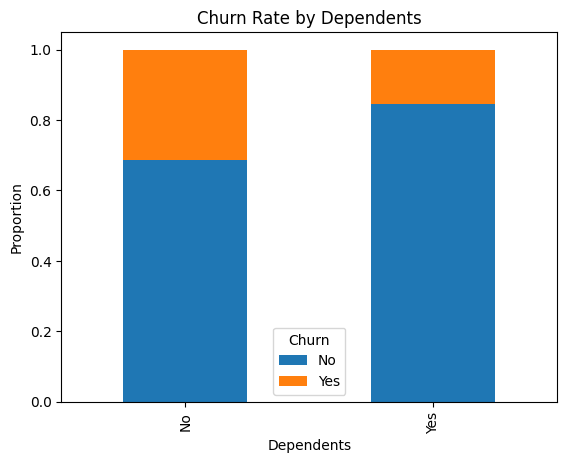

<Figure size 600x400 with 0 Axes>

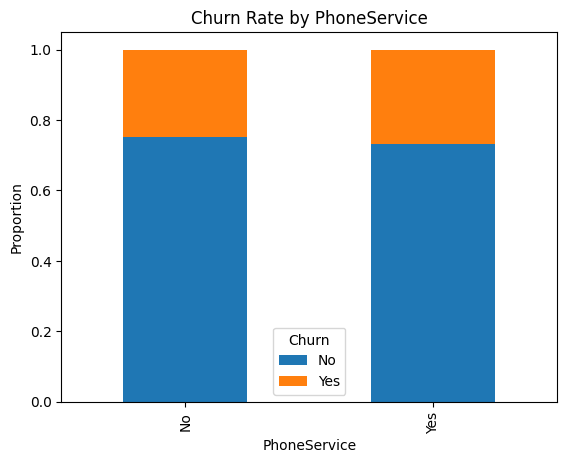

<Figure size 600x400 with 0 Axes>

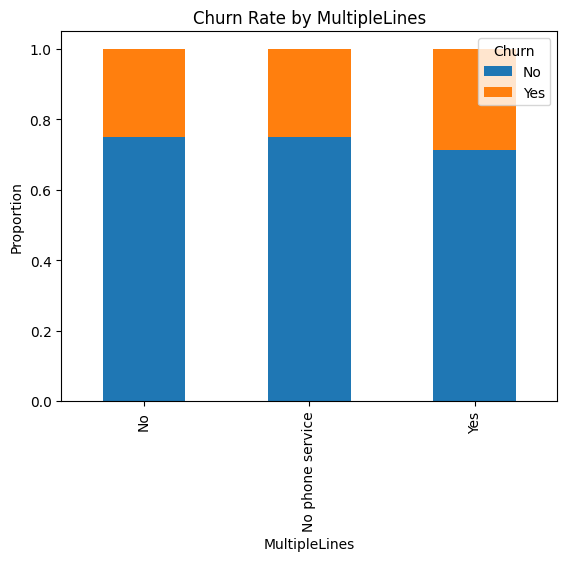

<Figure size 600x400 with 0 Axes>

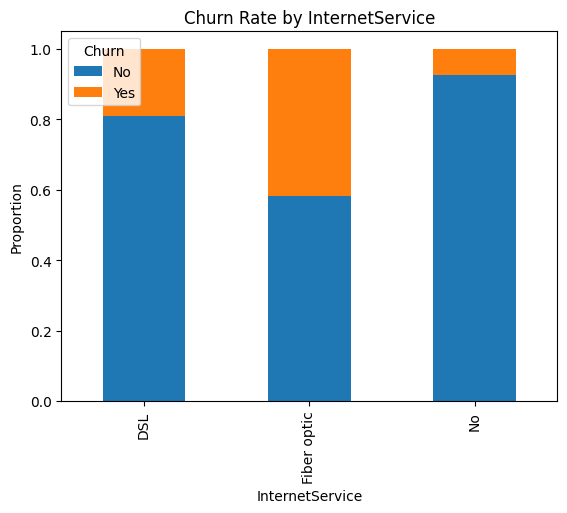

<Figure size 600x400 with 0 Axes>

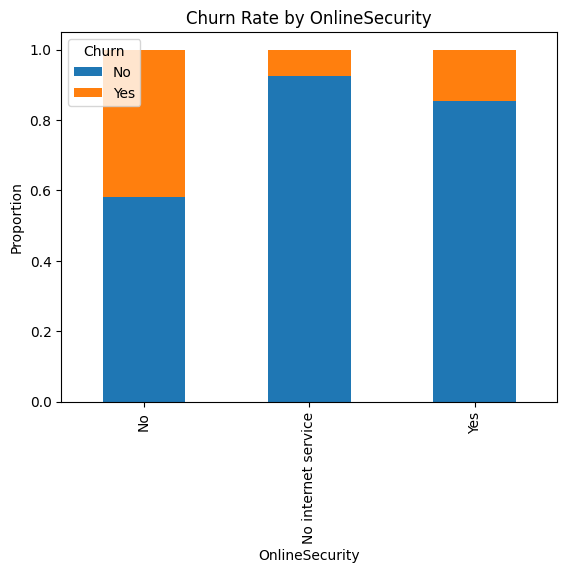

<Figure size 600x400 with 0 Axes>

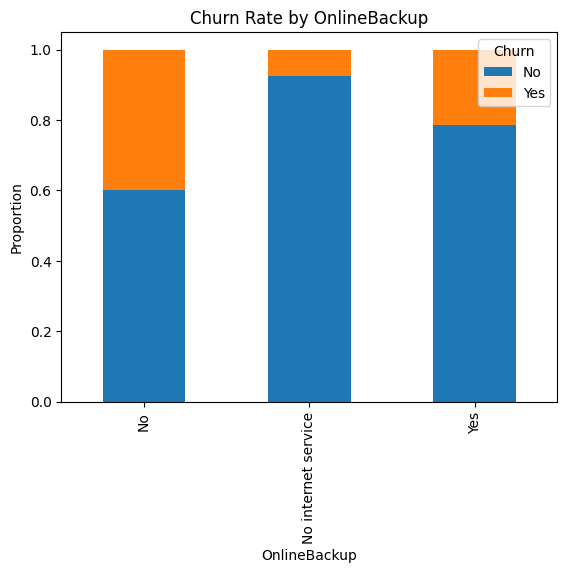

<Figure size 600x400 with 0 Axes>

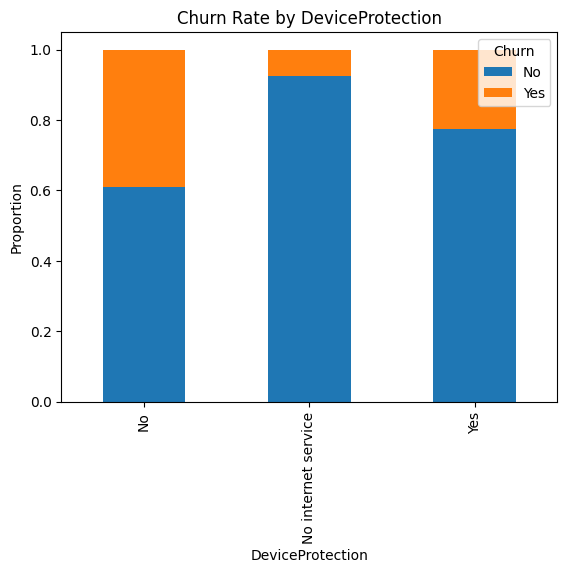

<Figure size 600x400 with 0 Axes>

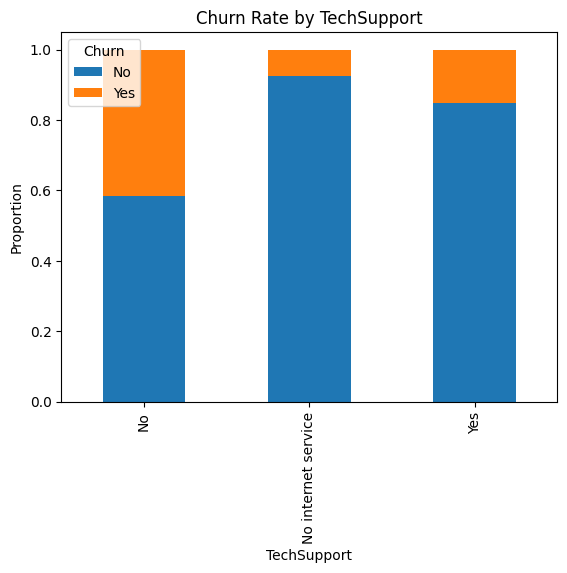

<Figure size 600x400 with 0 Axes>

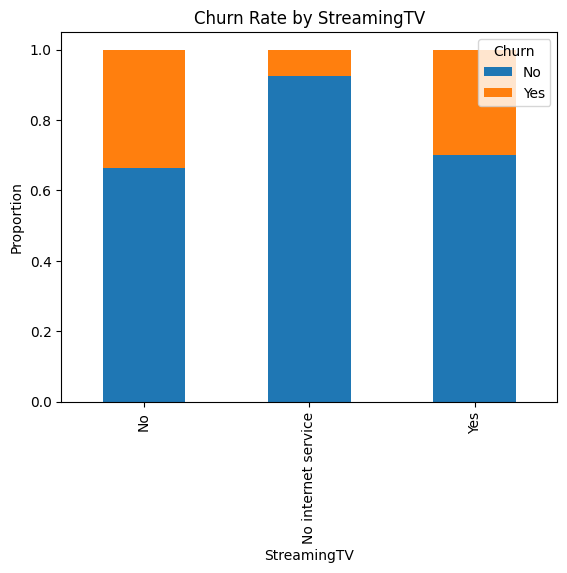

<Figure size 600x400 with 0 Axes>

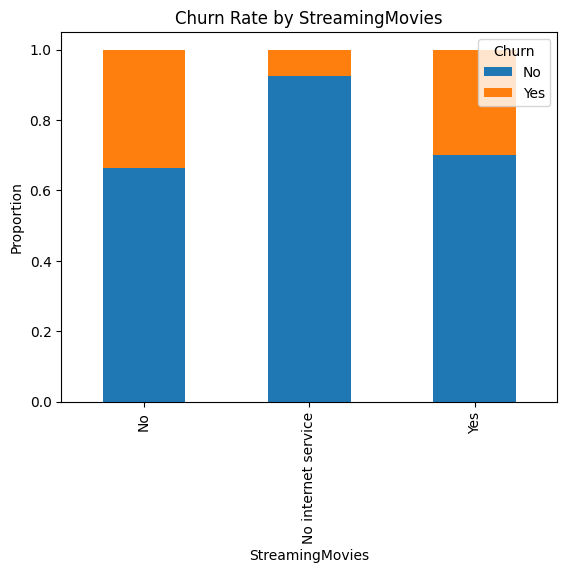

<Figure size 600x400 with 0 Axes>

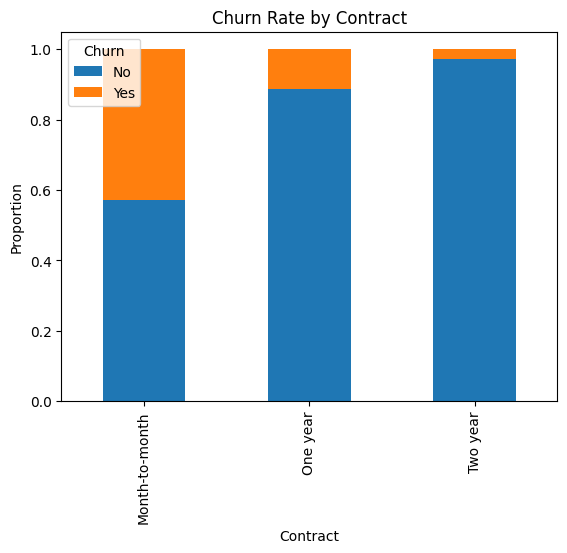

<Figure size 600x400 with 0 Axes>

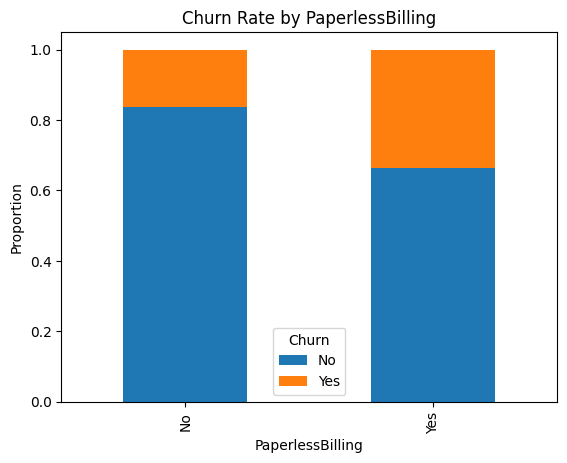

<Figure size 600x400 with 0 Axes>

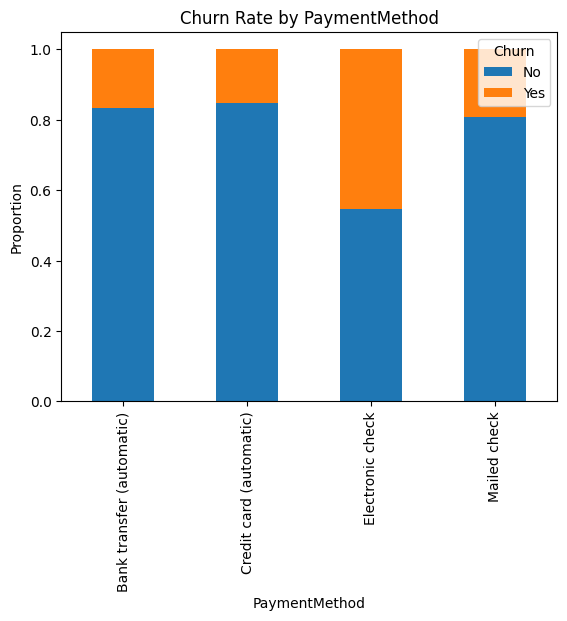

<Figure size 600x400 with 0 Axes>

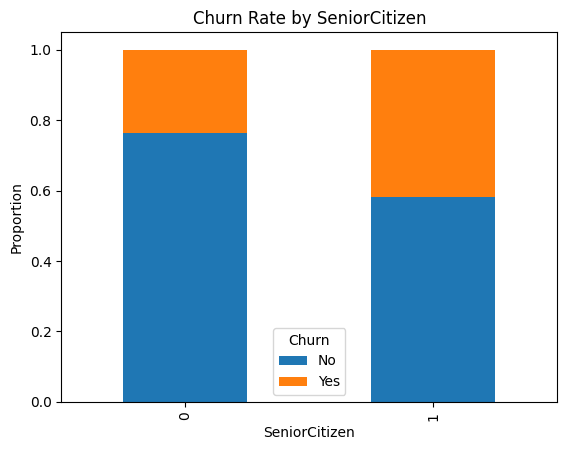

In [171]:
for col in categorical_cols:

    plt.figure(figsize=(6,4))

    churn_rate = pd.crosstab(df[col], df['Churn'], normalize="index")
    churn_rate.plot(kind="bar", stacked=True)

    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Proportion")
    plt.legend(title="Churn")

    plt.show()

# Observation for gender :
Churn rate between male and female customers is almost identical.

Implication:
Gender does not appear to be a strong predictor of churn.
The feature will be retained for modeling but may have limited predictive value.

# Observation for partner : 
Observation:
Customers without a partner show a noticeably higher churn rate (~33%)
compared to customers with a partner (~20%).

Implication:
Having a partner may indicate a more stable household or shared services,
which can reduce the likelihood of churn.
The Partner feature may provide useful predictive signal for the churn model.

# oberservation for dependents: 
Observation:
Customers without dependents show a significantly higher churn rate (~31%)
compared to customers with dependents (~16%).

Implication:
Customers with financial dependents appear to have more stable service usage
and are less likely to churn. The Dependents feature may provide useful
predictive signal for the churn prediction model.

# oberservation for phone service: 
Observation:
The churn rate between customers with and without phone service appears nearly identical. The proportion of churned customers is roughly similar in both groups, indicating minimal difference in churn behavior.

Implication:
PhoneService does not appear to provide strong predictive signal for customer churn. This feature may have limited standalone predictive value, but it will be retained initially and evaluated further during model training and feature importance analysis.


# oberservation for multiple phone lines: 
Observation:
The churn rate across MultipleLines categories appears very similar. Customers with multiple phone lines show only a slightly higher churn proportion compared to customers with a single line or no phone service, but the difference is minimal.

Implication:
MultipleLines does not appear to provide strong standalone predictive signal for churn. The feature will be retained initially, but it is likely to have limited influence on the churn prediction model.


# Observation for internet service:
Observation:
Customers using Fiber Optic internet service show a significantly higher churn rate compared to DSL users and customers without internet service. The churn proportion for Fiber Optic customers appears substantially larger.

Implication:
InternetService appears to be a strong predictor of churn, particularly for Fiber Optic users. This feature likely contains meaningful predictive signal and should be retained for modeling. Further analysis may explore interactions between InternetService and other service-related features.


# Observation for online securities :
Observation:
Customers without OnlineSecurity show a significantly higher churn rate compared to customers who have the OnlineSecurity service enabled. Customers with no internet service exhibit the lowest churn rate.

Implication:
OnlineSecurity appears to have strong predictive signal for churn. Customers who subscribe to additional security services may be more engaged with the provider's ecosystem and therefore less likely to churn. This feature should be retained for modeling and may interact with other internet-related services.


# Observation for OnlineBackup :
Observation:
Customers without OnlineBackup show a significantly higher churn rate compared to customers who subscribe to the OnlineBackup service. Customers without internet service exhibit the lowest churn rate.

Implication:
OnlineBackup appears to provide meaningful predictive signal for churn. Customers who purchase additional internet-related services may be more engaged with the provider's ecosystem and therefore less likely to churn.

# Observation for DeviceProtection :
Observation:
Customers without DeviceProtection show a noticeably higher churn rate compared to customers who subscribe to the DeviceProtection service. Customers without internet service exhibit the lowest churn rate.

Implication:
DeviceProtection appears to have meaningful predictive signal for churn. Customers who purchase additional device protection services may be more engaged with the provider’s ecosystem and therefore less likely to churn.

# Customer Add-on Service Behavior and Its Impact on Churn : 
Observation:
Several internet-related add-on services (OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport) show similar churn patterns. Customers who subscribe to these services generally exhibit lower churn rates.

Interpretation:
These services appear to represent a similar behavioral pattern: customers who purchase additional services may be more engaged with the provider ecosystem.

Feature Engineering Idea:
A potential derived feature could represent the number of add-on services subscribed by a customer (e.g., num_addon_services). This aggregated feature may capture the overall level of customer engagement with optional services.


# Observation for Customer Support :
Observation:
Customers without TechSupport show a significantly higher churn rate compared to customers who subscribe to the TechSupport service. Customers without internet service exhibit the lowest churn rate.

Implication:
TechSupport appears to provide strong predictive signal for churn. Access to technical support may improve customer experience and reduce the likelihood of service dissatisfaction, which helps retain customers.


# Observation for Streaming TV and Movies : 
Observation:
Customers who subscribe to StreamingTV or StreamingMovies show only slightly lower churn rates compared to customers without these services. The difference between the categories appears relatively small.

Implication:
Streaming-related services do not appear to provide strong standalone predictive signal for churn. Unlike security or support-related add-ons, entertainment services may not significantly increase customer retention.


# Observation for contract : 
Observation:
Customers with month-to-month contracts show the highest churn rate. Customers with one-year contracts churn significantly less, while customers with two-year contracts exhibit the lowest churn rate.

Implication:
Contract duration appears to be a strong predictor of churn. Longer contracts likely increase customer commitment and switching costs, reducing the likelihood of churn. This feature should be retained for modeling and is expected to have high predictive importance.

# Observation for paperless billing : 
Observation:
Customers who use paperless billing show a noticeably higher churn rate compared to customers who receive traditional paper billing.

Implication:
PaperlessBilling appears to have moderate predictive signal for churn. This feature may reflect behavioral differences between digital-first customers and traditional customers, rather than being a direct cause of churn.


# Observation for Payment method : 
Observation:
Customers who pay using electronic check exhibit a significantly higher churn rate compared to customers using automatic payment methods such as bank transfer or credit card.

Implication:
PaymentMethod appears to have strong predictive signal for churn. Automatic payment methods may indicate more stable and committed customers, while manual payment methods may reflect more flexible or price-sensitive users.


# Observation for Senior Citizen : 
Observation:
Senior customers exhibit a noticeably higher churn rate compared to non-senior customers.

Implication:
SeniorCitizen may provide moderate predictive signal for churn. This feature may capture differences in customer behavior or service usage patterns across age groups and could help the model identify higher-risk customer segments.


# Primary churn drivers
Contract
PaymentMethod
InternetService
Support/Add-on services

# Secondary drivers
Partner
Dependents
SeniorCitizen
PaperlessBilling

# Weak drivers
Gender
PhoneService
MultipleLines
Streaming services


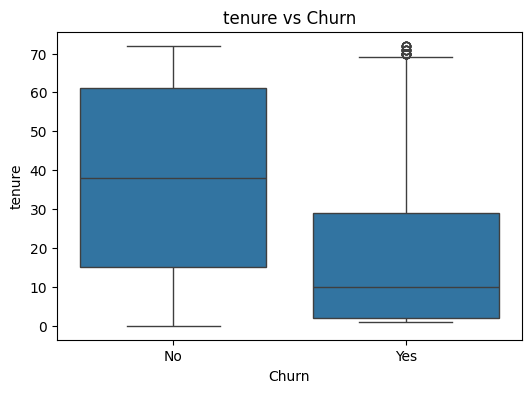

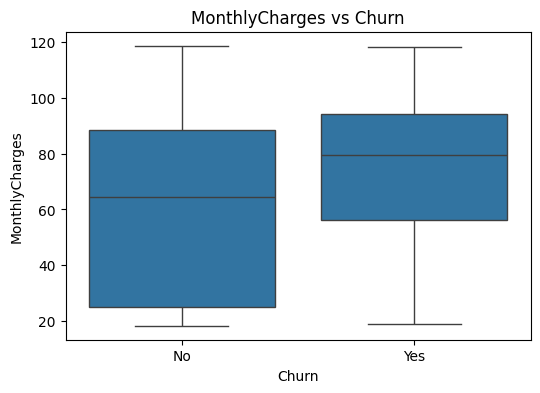

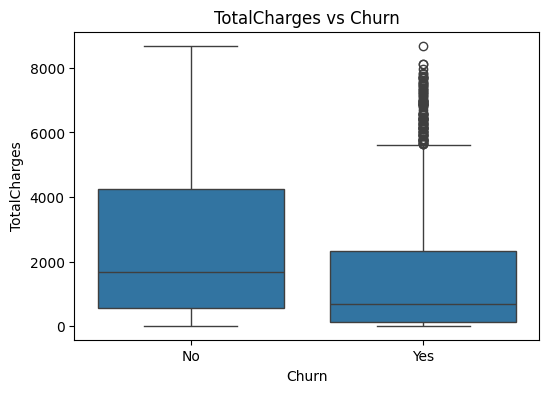

In [174]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(data=df, x=df['Churn'], y=col)

    plt.title(f"{col} vs Churn")

    plt.show()

# Obersevation for tenure: 
Observation:
Customers who churn tend to have significantly shorter tenure compared to customers who remain with the service. The median tenure for churned customers appears substantially lower.

Implication:
Tenure appears to be a strong predictor of churn. Customers with shorter subscription durations are more likely to leave the service. Feature engineering techniques such as tenure binning may help capture nonlinear churn patterns across different customer lifecycle stages.


# Observation for monthly charga :
Observation:
Customers who churn tend to have higher monthly charges compared to customers who remain with the service. The median monthly charge for churned customers appears noticeably higher.

Implication:
MonthlyCharges may provide moderate predictive signal for churn. Higher-priced service plans may lead to increased churn risk, possibly due to price sensitivity or higher customer expectations.


# Observation for total charge : 
Observation:
Customers who churn tend to have significantly lower total charges compared to customers who remain with the service. The distribution shows a much lower median TotalCharges for churned customers.

Implication:
TotalCharges appears to be strongly related to churn behavior, largely reflecting the relationship between tenure and accumulated spending. Customers who churn typically have shorter service duration and therefore lower total accumulated charges.



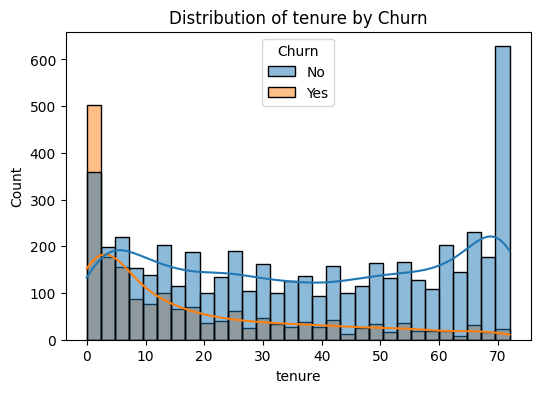

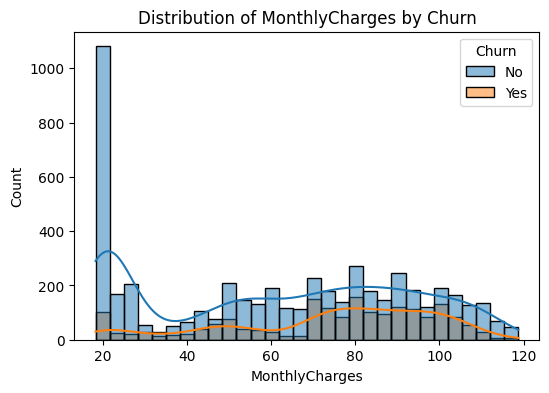

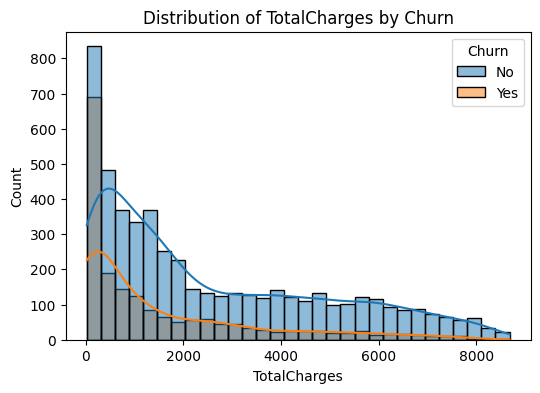

In [176]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(data=df, x=col, hue=df['Churn'], bins=30, kde=True)

    plt.title(f"Distribution of {col} by Churn")

    plt.show()

# Observation for distribution tenure by churn : 
Observation:
Customers who churn are heavily concentrated in the early tenure range, particularly within the first 10–12 months. As tenure increases, the proportion of churned customers decreases significantly.

Implication:
Tenure appears to be a strong predictor of churn, particularly during the early stages of the customer lifecycle. Customers who remain subscribed for longer periods are much less likely to churn.


# Observation for distribution Monthly Charge by churn : 
Observation:
Customers with higher monthly charges tend to exhibit a higher churn rate compared to customers with lower monthly charges.

Implication:
MonthlyCharges appears to contain useful predictive signal for churn. Customers paying higher monthly fees may be more price-sensitive or may have higher expectations regarding service quality.

# Observation for distribution Total Charge by churn : 
Observation:
Customers who churn tend to have significantly lower TotalCharges compared to customers who remain subscribed.

Implication:
TotalCharges reflects the accumulated payments made by a customer over time. Lower values often correspond to newer customers, suggesting that churn occurs more frequently during the early stages of the customer lifecycle.


# Insight : 
tenure → strong predictor

MonthlyCharges → moderate predictor

TotalCharges → proxy tenure


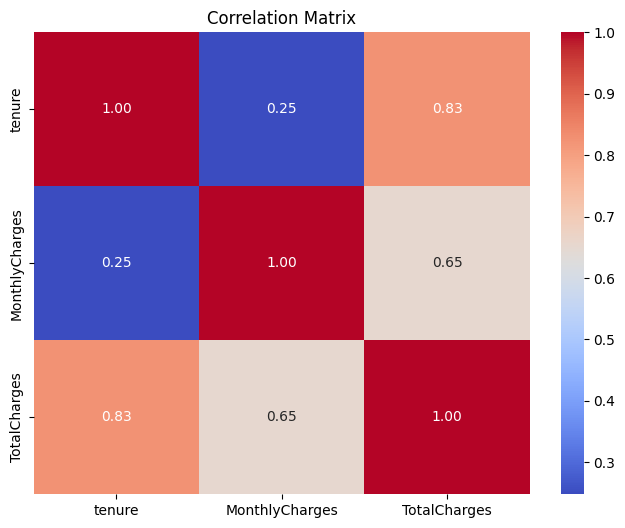

In [178]:
plt.figure(figsize=(8,6))

corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

# Corellation matrix analysis :
Total charges does correlate highly with tenure at 0.85. Since TotalCharge is similar and derived function, we can safe to assume to remove TotalCharge and use only tenure with MonthlyCharge

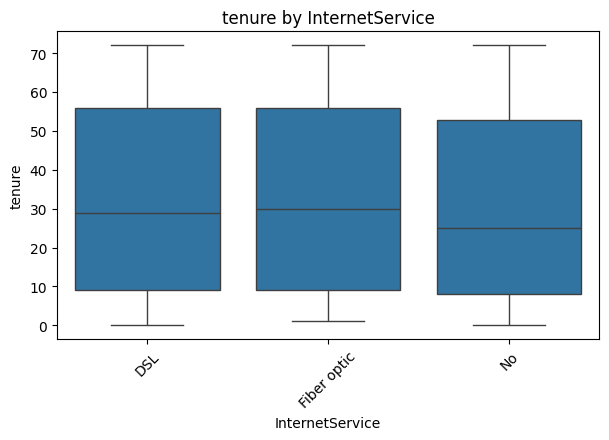

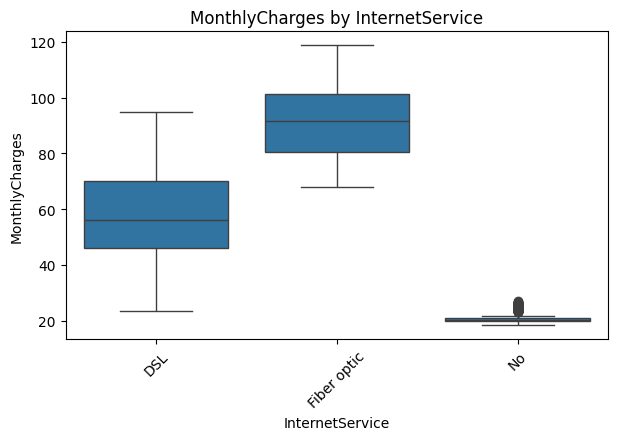

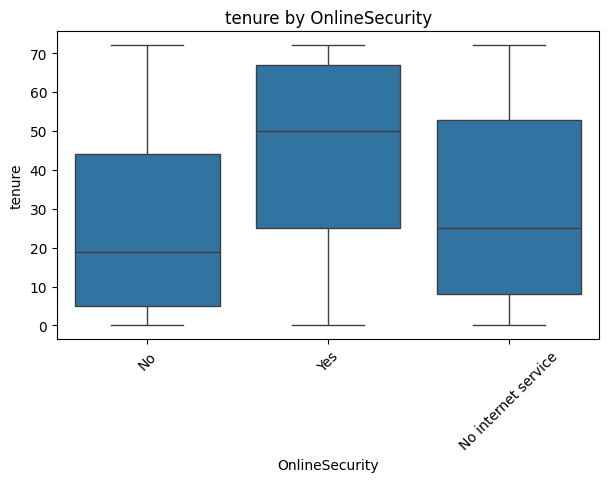

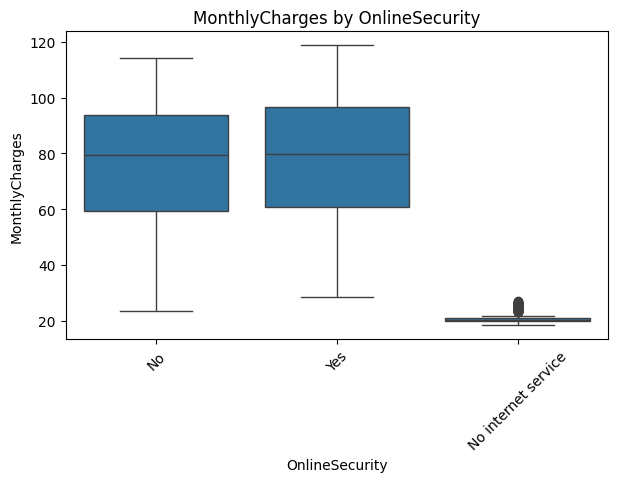

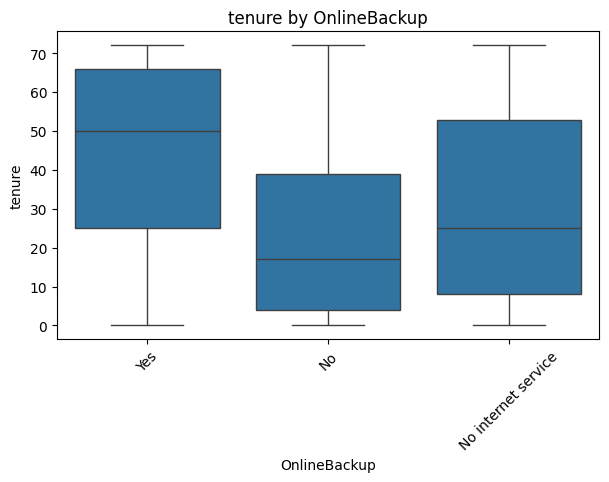

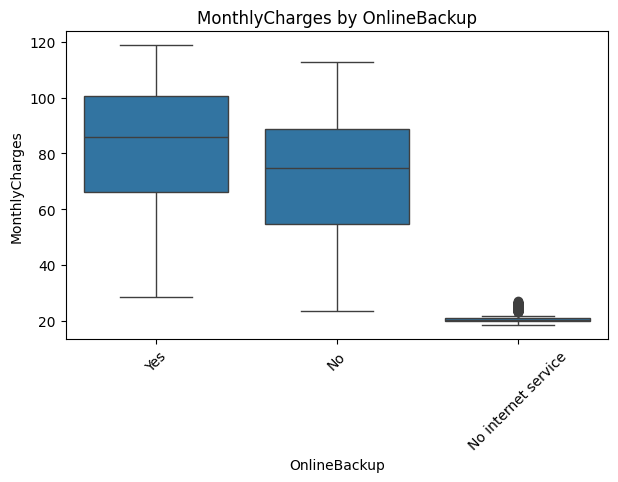

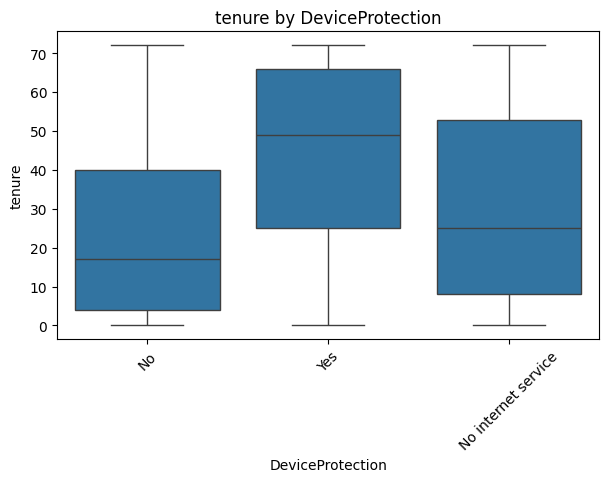

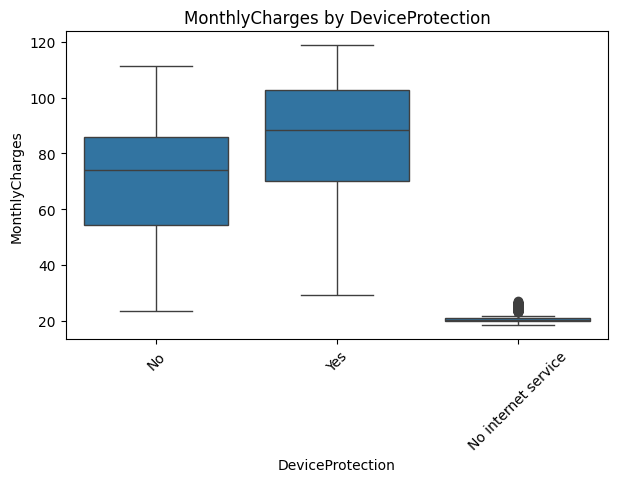

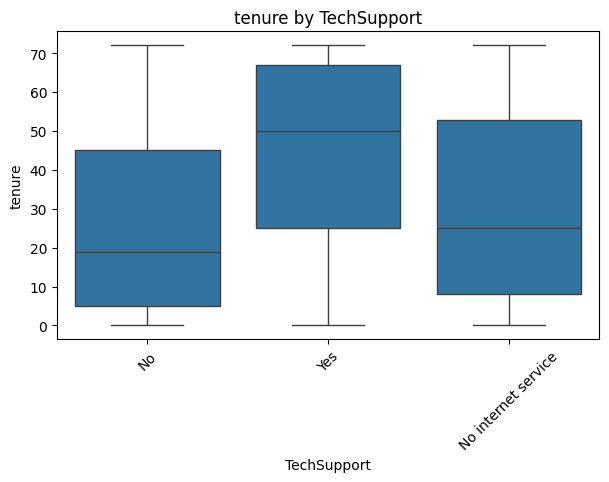

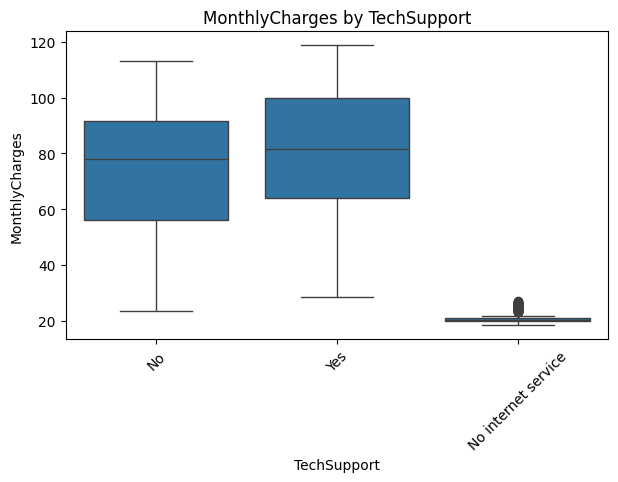

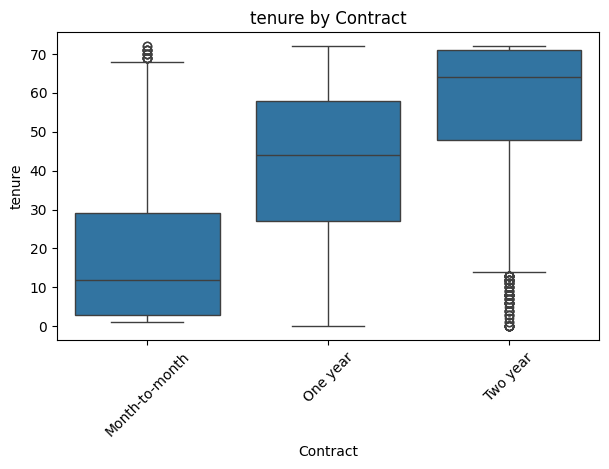

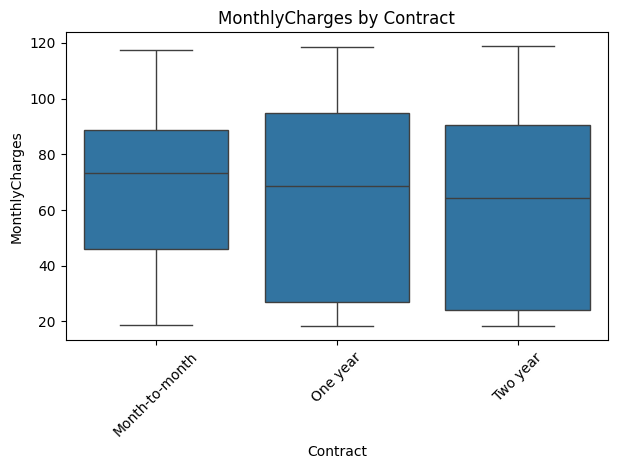

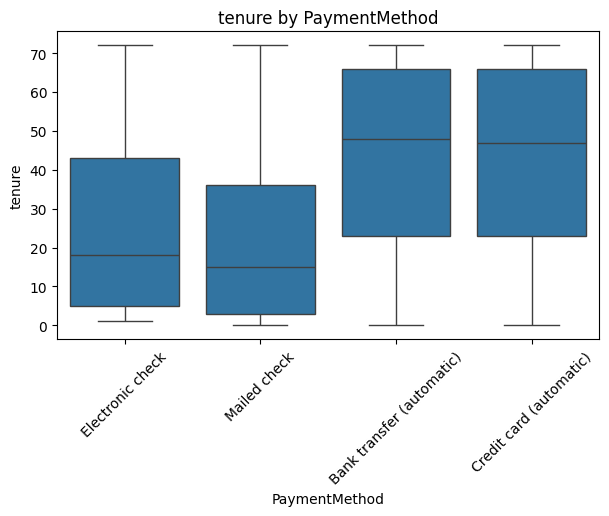

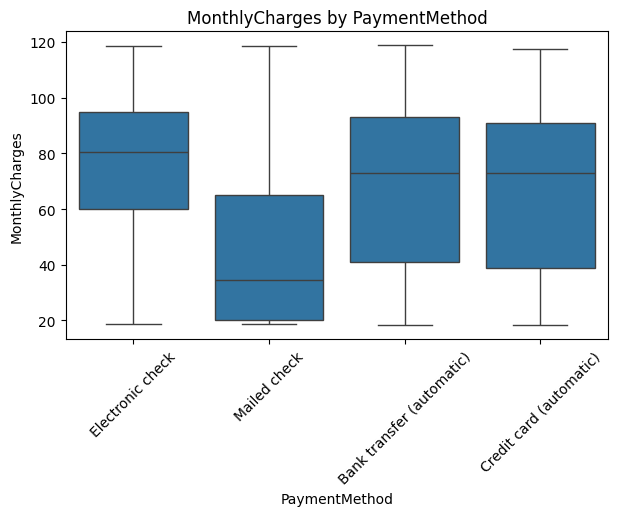

In [186]:
# Filter only strong signal feature

numerical_columns = ["tenure", "MonthlyCharges"]

important_cat = [
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "Contract",
    "PaymentMethod"
]


for cat in important_cat:

    for num in numerical_columns:

        plt.figure(figsize=(7,4))

        sns.boxplot(data=df, x=cat, y=num)

        plt.xticks(rotation=45)

        plt.title(f"{num} by {cat}")

        plt.show()

# # Observation for tenure to internet service : 
The distribution of customer tenure is very similar across all Internet service types (DSL, Fiber optic, and No internet). The median tenure for each category is close, and the interquartile ranges largely overlap. No service category shows a noticeably longer or shorter tenure pattern compared to the others.

Implication:
Internet service type does not appear to strongly influence how long customers stay subscribed. Tenure behavior is relatively consistent regardless of the Internet service category, suggesting that InternetService alone is unlikely to be a strong driver of customer tenure differences.

# Observation for Monthly Charge to internetServices : 
Monthly charges differ substantially across Internet service types. Customers with Fiber optic service show the highest monthly charges, with a median around the high range (~90+). DSL users have moderate monthly charges with a lower median (~55–60). Customers without internet service have the lowest monthly charges, tightly concentrated around ~20.

Implication:
Internet service type strongly influences the monthly price customers pay. Fiber optic service is associated with significantly higher monthly charges compared to DSL and customers without internet service. This indicates that InternetService is likely a major pricing driver and may interact with MonthlyCharges when explaining customer behavior such as churn.



# Observation for tenure to online security  : 
Monthly charges vary significantly across different Internet service types. Customers with Fiber optic service have the highest monthly charges, with a median around ~90. DSL customers have moderate charges with a median around ~55–60. Customers without internet service have the lowest monthly charges, tightly concentrated around ~20 with very little variation.

Implication:
InternetService appears to be a primary driver of pricing differences among customers. Fiber optic service is associated with substantially higher monthly charges compared to DSL and customers without internet service. This suggests that InternetService plays an important role in determining MonthlyCharges and may influence customer behavior, particularly when analyzing patterns related to churn.

# Observation for Monthly Charge to online security  : 
Monthly charges are relatively similar between customers with and without OnlineSecurity, with both groups showing a median around ~80 and a wide distribution ranging roughly from ~60 to ~100. In contrast, customers labeled as having “No internet service” show much lower monthly charges, tightly concentrated around ~20 with minimal variation.

Implication:
Having OnlineSecurity does not appear to substantially change the monthly charges among customers who already have internet service. The major difference in monthly charges is instead driven by whether customers have internet service at all. This suggests that OnlineSecurity itself is not a primary pricing driver, but rather an add-on feature within existing internet service plans.


# Observation for Tenure by online Backup  : 
Customers with OnlineBackup show significantly longer tenure compared to those without it. The median tenure for customers with OnlineBackup is around ~50 months, while customers without OnlineBackup have a much lower median tenure of roughly ~17 months. Customers without internet service fall in between but still show lower tenure compared to those who actively use OnlineBackup.

Implication :
OnlineBackup appears to be associated with longer customer retention. Customers who subscribe to backup services tend to stay with the company for a longer period, suggesting that engagement with additional services may correlate with higher customer loyalty and lower likelihood of churn.

# Observation for Monthly Charge by online Backup  :
Customers who subscribe to OnlineBackup tend to have higher monthly charges, with a median around ~85, compared to customers without OnlineBackup whose median monthly charge is around ~75. Customers without internet service have significantly lower monthly charges concentrated around ~20.

Implication :
OnlineBackup appears to increase the monthly subscription cost, suggesting it functions as a paid add-on service within internet packages. Customers who opt for OnlineBackup are therefore likely paying for a more feature-rich or premium service plan.


# Observation for Tenure by Device protection  :
Customers with DeviceProtection show significantly longer tenure compared to those without it. The median tenure for customers with DeviceProtection is around ~49 months, while customers without DeviceProtection have a much lower median around ~17 months. Customers without internet service fall between these two groups.

Implication :
Customers who subscribe to DeviceProtection tend to stay with the service for longer periods. This suggests that customers who adopt additional protection services are generally more engaged or more established customers, which may correlate with stronger customer retention.

# Observation for Monthly Charge by Device protection  :
Customers with DeviceProtection tend to have higher monthly charges compared to those without it. The median monthly charge for customers with DeviceProtection is around ~88–90, while customers without DeviceProtection have a lower median around ~73–75. Customers without internet service have significantly lower monthly charges concentrated around ~20.

Implication :
DeviceProtection appears to function as a paid add-on service that increases the total monthly subscription cost. Customers who subscribe to DeviceProtection are therefore likely paying for a more comprehensive or premium service bundle.

# Observation for Tenure by Tech support  :
Customers with TechSupport tend to have significantly longer tenure compared to customers without TechSupport. The median tenure for customers with TechSupport is around ~50 months, while customers without TechSupport show a much lower median around ~19 months. Customers without internet service fall between these two groups.

Implication :
TechSupport appears to be associated with longer customer retention. Customers who subscribe to technical support services tend to stay with the company for a longer period, suggesting that additional service engagement may correlate with stronger customer loyalty and reduced likelihood of churn.

# Observation for Monthly Charges by Tech support  :
Customers who subscribe to TechSupport tend to have slightly higher monthly charges compared to customers without TechSupport. The median monthly charge for customers with TechSupport is around ~82, while customers without TechSupport show a slightly lower median around ~78. Customers without internet service have significantly lower monthly charges concentrated around ~20.

Implication :
TechSupport appears to function as a paid add-on feature that slightly increases the total monthly subscription cost. Combined with earlier observations that customers with TechSupport also tend to have longer tenure, this suggests that customers paying for higher-value service bundles may be more engaged and potentially less likely to churn.

# Observation for Tenure by contract  :
Customer tenure increases significantly with longer contract types. Month-to-month customers show the shortest tenure with a median around ~12 months, while one-year contracts have a higher median around ~44 months. Two-year contract customers exhibit the longest tenure with a median around ~64 months.

Implication :
Contract length appears to be strongly associated with customer retention. Customers with longer-term contracts tend to remain subscribed for much longer periods, while month-to-month customers are typically newer and more flexible in leaving the service. This suggests that contract commitment may play a significant role in customer stability and churn behavior.

# Observation for Monthly Charge by contract  :
Monthly charges are relatively similar across different contract types. The median monthly charges for month-to-month, one-year, and two-year contracts are close, with substantial overlap in their distributions.

Implication :
Contract type does not appear to strongly influence the monthly subscription price. Instead, pricing is likely driven by the service package and add-on features, while contract length primarily reflects customer commitment rather than pricing structure.

# Observation for Tenure by Payment Method  :
Customers using automatic payment methods such as bank transfer or credit card tend to have significantly longer tenure, with median tenure around ~47–48 months. In contrast, customers using manual payment methods such as electronic check or mailed check show much lower median tenure around ~15–18 months.

Implication :
PaymentMethod appears to be strongly associated with customer retention. Customers who use automatic payment methods tend to remain subscribed for much longer periods, suggesting that automatic billing may reflect higher customer commitment and lower likelihood of churn.

# Observation for Monthly Charge by Payment Method  :
Monthly charges vary across payment methods. Customers using electronic check tend to have the highest monthly charges, with a median around ~80. Customers paying via bank transfer (automatic) or credit card (automatic) show moderately high monthly charges with medians around ~70–75. In contrast, customers using mailed check tend to have significantly lower monthly charges, with a median around ~35.

Implication:
Payment method appears to be associated with differences in pricing tiers or service packages. Customers paying via electronic check are more likely to have higher monthly charges, while those using mailed check tend to subscribe to lower-cost plans. Automatic payment methods fall in the middle, suggesting that payment behavior may reflect different customer segments or billing preferences rather than directly determining pricing.


# Strong feature by pattern : 
tenure
Contract
PaymentMethod

# Feature explain price packet : 
InternetService
OnlineBackup
DeviceProtection
TechSupport

# possible feature interaction : 
tenure * MonthlyCharges
AutoPay (derived from PaymentMethod)

## Feature Engineering Considerations

After completing the bivariate analysis between numerical and categorical variables, several structural patterns in the dataset become clear. The analysis mainly helps understand how different service attributes relate to pricing, customer lifecycle, and potential retention behavior.

### 1. Strong Natural Predictors

Some features already contain strong predictive signals and do not require additional transformation. These variables directly represent customer lifecycle, commitment level, or pricing structure.

**Key features identified:**

- `tenure`
- `Contract`
- `PaymentMethod`
- `MonthlyCharges`

**Interpretation:**

- **tenure** represents the lifecycle stage of the customer. Customers with longer tenure are typically more stable and less likely to churn.
- **Contract** reflects commitment level. Customers on long-term contracts tend to stay longer than those on month-to-month plans.
- **PaymentMethod** reveals behavioral patterns. Customers using automatic payment methods tend to have longer tenure and higher stability.
- **MonthlyCharges** captures the pricing tier of the service package.

These features already encode important behavioral and economic signals and therefore can be used directly in the model.

---

### 2. Service Bundle Features

Several variables represent **service add-ons** or product configuration rather than customer behavior directly.

These include:

- `InternetService`
- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`

From the exploratory analysis:

- These features primarily explain **differences in service bundles**.
- Many of them influence **MonthlyCharges** because they represent optional service upgrades.
- Customers who subscribe to additional services often show **longer tenure**, indicating higher engagement.

Although these variables may not independently drive churn, they provide useful context about the **customer’s service configuration** and should still be included in the model.

---

### 3. Potential Derived Features

The dataset already contains informative variables, so only minimal feature engineering is required. However, a few additional derived features may capture useful behavioral signals.

#### AutoPay Indicator

Payment methods can be grouped into **automatic vs manual payments**.

**Definition:**
AutoPay = 1 if PaymentMethod is automatic
AutoPay = 0 otherwise


Automatic payment methods include:

- Bank transfer (automatic)
- Credit card (automatic)

Manual methods include:

- Electronic check
- Mailed check

**Rationale:**

Automatic billing often reflects stronger customer commitment and may correlate with lower churn probability.

---

#### Customer Value Proxy

Another useful interaction feature combines tenure and monthly charges.

**Definition:**
CustomerValue = tenure * MonthlyCharges


**Rationale:**

This variable approximates the total value generated by a customer over time and helps capture the interaction between:

- how long the customer has stayed
- how much they pay monthly

Customers with **high monthly charges but short tenure** may represent higher churn risk, while customers with **long tenure and stable charges** are typically more loyal.

---

### 4. Feature Engineering Not Required

The exploratory analysis did not reveal strong evidence for complex interactions between service add-ons. For example, interactions such as:

- `InternetService × OnlineBackup`
- `DeviceProtection × TechSupport`
- `Contract × PaymentMethod`

do not show clear patterns that justify additional engineered variables.

In this dataset, most information is already well captured by the original features.

---

### 5. Final Feature Set

The modeling dataset can therefore use a relatively compact feature set.

**Numerical Features**

- `tenure`
- `MonthlyCharges`

**Derived Numerical Feature**

- `CustomerValue = tenure × MonthlyCharges`

**Categorical Features**

- `InternetService`
- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`
- `Contract`
- `PaymentMethod`

**Derived Categorical Feature**

- `AutoPay`

---

### Summary

The exploratory analysis suggests that the dataset already contains well-structured variables. Rather than relying on heavy feature engineering, the model can focus on a small set of meaningful features representing:

1. **Customer lifecycle** → `tenure`
2. **Pricing structure** → `MonthlyCharges`
3. **Customer commitment** → `Contract`, `PaymentMethod`
4. **Service configuration** → internet service and add-on features

A limited number of derived features such as **AutoPay** and **CustomerValue** may help capture additional behavioral signals while keeping the feature space interpretable.
